# Locally Weighted Learning (LWL)
**Investigación en Grupo | Módulo: DEVOPS E INTELIGENCIA ARTIFICIAL**

---

## 1. Descripción del Algoritmo

**Locally Weighted Learning (LWL)**, también conocido como **Locally Weighted Regression (LWR)** o **LOESS/LOWESS**, es un algoritmo de aprendizaje **no paramétrico** y **basado en instancias** (lazy learning). Fue desarrollado por **Cleveland y Devlin (1988)**.

La idea central es simple pero poderosa: en lugar de construir un modelo global con todos los datos, **para cada nueva consulta entrena un modelo local** usando solo los puntos de datos más cercanos a esa consulta, asignándoles mayor peso cuanto más cercanos estén.

Es como si en lugar de tomar una foto panorámica de todos los datos, hicieras un zoom en la zona que te interesa para cada predicción.

### Diferencia clave con otros algoritmos:
- **Regresión Lineal global**: entrena UNA vez con todos los datos → aplica el mismo modelo a todo
- **LWL**: NO entrena previamente → para cada punto nuevo, busca sus vecinos más cercanos y entrena un modelo local en ese momento

## 2. Publicación que Propuso el Algoritmo (BibTeX y Referencias)

### BibTeX Original — LOWESS
```bibtex
@article{cleveland1979robust,
  title   = {Robust locally weighted regression and smoothing scatterplots},
  author  = {Cleveland, William S.},
  journal = {Journal of the American Statistical Association},
  volume  = {74},
  number  = {368},
  pages   = {829--836},
  year    = {1979},
  publisher = {Taylor & Francis}
}
```

### BibTeX — LWL aplicado a ML
```bibtex
@article{atkeson1997locally,
  title   = {Locally weighted learning},
  author  = {Atkeson, Christopher G. and Moore, Andrew W. and Schaal, Stefan},
  journal = {Artificial Intelligence Review},
  volume  = {11},
  number  = {1-5},
  pages   = {11--73},
  year    = {1997},
  publisher = {Springer}
}
```

### Referencias APA
- Cleveland, W. S. (1979). Robust locally weighted regression and smoothing scatterplots. *Journal of the American Statistical Association, 74*(368), 829–836.
- Atkeson, C. G., Moore, A. W., & Schaal, S. (1997). Locally weighted learning. *Artificial Intelligence Review, 11*(1-5), 11–73.

## 3. Tipo de Modelo

| Dimensión | Clasificación |
|---|---|
| **Método de Aprendizaje** | Aprendizaje Supervisado — Regresión y Clasificación |
| **Por Parámetros** | No Paramétrico — no asume distribución de los datos |
| **Datos de Aprendizaje** | Lazy Learning (Online) — no entrena hasta recibir una consulta |
| **Resultado del Entrenamiento** | Basado en Instancias — no genera un modelo fijo, usa los datos directamente |

## 4. Algoritmo de Entrenamiento

LWL usa una **función de peso (kernel)** para asignar importancia a cada punto según su distancia a la consulta.

### Función de peso (Kernel Gaussiano — el más común):
$$w_i = \exp\left(-\frac{(x_i - x_q)^2}{2\tau^2}\right)$$

Donde:
- $x_i$ = punto de entrenamiento
- $x_q$ = punto de consulta (nueva muestra)
- $\tau$ = ancho de banda (bandwidth) — controla qué tan lejos llega la influencia
- $w_i$ = peso asignado (entre 0 y 1, mayor = más cercano)

### Proceso paso a paso:
1. Llega una nueva consulta $x_q$
2. Calcular distancia de $x_q$ a todos los puntos de entrenamiento
3. Asignar pesos con la función kernel (cercanos → peso alto, lejanos → peso bajo)
4. Entrenar una regresión ponderada LOCAL con esos pesos
5. Hacer la predicción para $x_q$
6. **Descartar el modelo** — el próximo punto repetirá el proceso

## 5. Tipos de Entrada

- **Variables numéricas continuas** — ideal para datos donde la relación entre variables cambia en distintas zonas
- **Series temporales** — muy usado para suavizar datos de tiempo
- **Datos con relaciones no lineales** — donde una regresión global no funciona bien
- **Conjuntos de datos pequeños a medianos** — no escala bien con millones de datos por su costo computacional

## 6. Casos de Uso

| Área | Aplicación |
|---|---|
| 🤖 Robótica | Control de movimiento — aprende dinámicas locales del robot |
| 📈 Economía | Suavizado de tendencias en series de tiempo (PIB, inflación) |
| 🌡️ Meteorología | Interpolación de temperatura entre estaciones climáticas |
| 💊 Medicina | Análisis de dosis-respuesta en ensayos clínicos |
| 🚗 Vehículos autónomos | Modelado local del entorno de conducción |
| 📊 Finanzas | Estimación de volatilidad local en mercados financieros |

## 7. Supuestos y Restricciones

### Supuestos:
- Los puntos cercanos en el espacio de entrada tienen salidas similares
- La relación entre variables es localmente lineal (aunque globalmente no lo sea)
- Los datos de entrenamiento son representativos del espacio de predicción

### Restricciones:
- **Alto costo computacional** en predicción: debe recalcular para cada nueva consulta
- **Sensible al parámetro τ (bandwidth)**: muy pequeño → sobreajuste, muy grande → subajuste
- **No escala con grandes volúmenes de datos** (millones de registros)
- **Requiere todos los datos en memoria** durante la predicción
- No genera reglas interpretables como C4.5

## 8. Source Code — Implementación en Python

In [ ]:
# ============================================================
# PASO 1: Importar librerías
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [ ]:
# ============================================================
# PASO 2: Implementación de LWL desde cero
# El kernel Gaussiano asigna pesos según la distancia
# ============================================================
def kernel_gaussiano(x_query, x_train, tau):
    """
    Calcula los pesos para cada punto de entrenamiento.
    - x_query: el nuevo punto que queremos predecir
    - x_train: todos los puntos de entrenamiento
    - tau: ancho de banda (controla el rango de influencia)
    """
    distancias = (x_train - x_query) ** 2
    pesos = np.exp(-distancias / (2 * tau ** 2))
    return pesos

def lwl_predecir(x_query, X_train, y_train, tau):
    """
    Para cada punto de consulta:
    1. Calcula pesos usando el kernel
    2. Entrena una regresión ponderada local
    3. Retorna la predicción
    """
    predicciones = []
    for xq in x_query:
        # Calcular pesos para este punto de consulta
        pesos = kernel_gaussiano(xq, X_train, tau)
        W = np.diag(pesos)

        # Regresión ponderada: minimiza el error pesado por W
        X_b = np.column_stack([np.ones(len(X_train)), X_train])
        try:
            theta = np.linalg.inv(X_b.T @ W @ X_b) @ X_b.T @ W @ y_train
            pred = np.array([1, xq]) @ theta
        except:
            pred = np.mean(y_train)
        predicciones.append(pred)
    return np.array(predicciones)

print('✅ Funciones LWL definidas')

✅ Funciones LWL definidas


In [ ]:
# ============================================================
# PASO 3: Crear datos de prueba con relación no lineal
# LWL brilla cuando los datos no siguen una línea recta
# ============================================================
np.random.seed(42)
X_train = np.linspace(0, 2 * np.pi, 100)
y_train = np.sin(X_train) + np.random.normal(0, 0.2, 100)  # Seno + ruido

X_query = np.linspace(0, 2 * np.pi, 300)  # Puntos donde predecir

print(f' Datos de entrenamiento: {len(X_train)} puntos')
print(f' Puntos a predecir: {len(X_query)}')

 Datos de entrenamiento: 100 puntos
 Puntos a predecir: 300


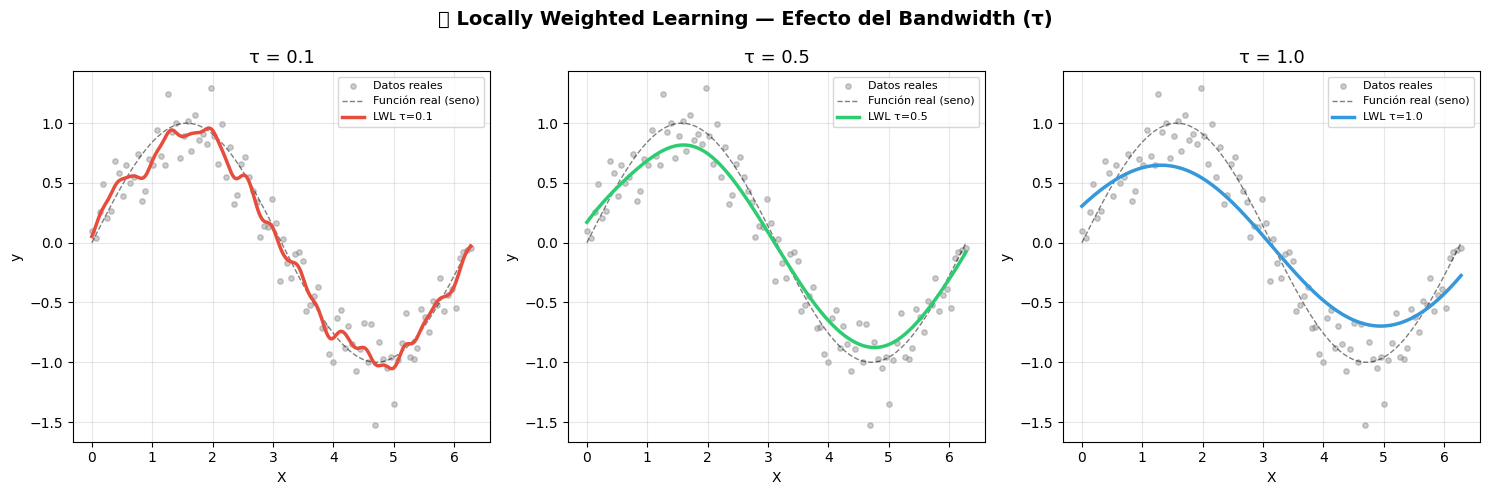

 Con τ=0.1 → sobreajuste  |  τ=0.5 → equilibrio  |  τ=1.0 → subajuste


In [ ]:
# ============================================================
# PASO 4: Comparar distintos valores de tau (bandwidth)
# tau pequeño = muy local (sobreajuste)
# tau grande  = muy global (subajuste)
# ============================================================
taus = [0.1, 0.5, 1.0]
colores = ['#e74c3c', '#2ecc71', '#3498db']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('🎯 Locally Weighted Learning — Efecto del Bandwidth (τ)', fontsize=14, fontweight='bold')

for ax, tau, color in zip(axes, taus, colores):
    y_pred = lwl_predecir(X_query, X_train, y_train, tau)

    ax.scatter(X_train, y_train, alpha=0.4, s=15, color='gray', label='Datos reales')
    ax.plot(X_query, np.sin(X_query), 'k--', linewidth=1, alpha=0.5, label='Función real (seno)')
    ax.plot(X_query, y_pred, color=color, linewidth=2.5, label=f'LWL τ={tau}')
    ax.set_title(f'τ = {tau}', fontsize=13)
    ax.legend(fontsize=8)
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(' Con τ=0.1 → sobreajuste  |  τ=0.5 → equilibrio  |  τ=1.0 → subajuste')

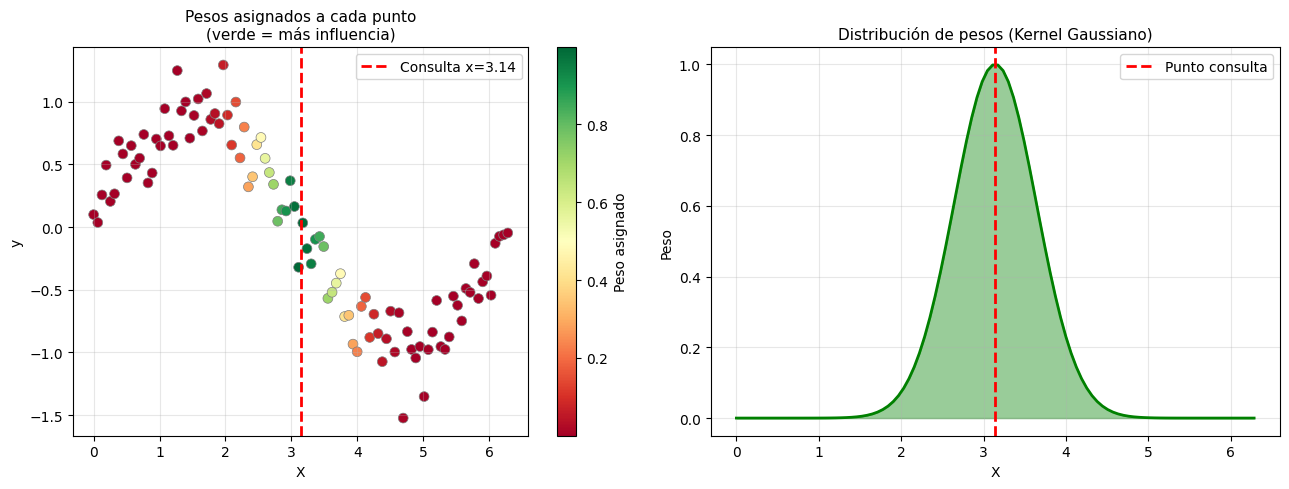

 Los puntos más cercanos al punto de consulta reciben mayor peso


In [ ]:
# ============================================================
# PASO 5: Visualizar cómo funcionan los pesos en LWL
# Para un punto de consulta, ver qué pesos asigna
# ============================================================
x_consulta = np.pi  # Punto que queremos predecir
tau = 0.5
pesos = kernel_gaussiano(x_consulta, X_train, tau)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pesos asignados
sc = axes[0].scatter(X_train, y_train, c=pesos, cmap='RdYlGn', s=50, edgecolors='gray', linewidth=0.5)
axes[0].axvline(x=x_consulta, color='red', linestyle='--', linewidth=2, label=f'Consulta x={x_consulta:.2f}')
plt.colorbar(sc, ax=axes[0], label='Peso asignado')
axes[0].set_title('Pesos asignados a cada punto\n(verde = más influencia)', fontsize=11)
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución de pesos
axes[1].fill_between(X_train, pesos, alpha=0.4, color='green')
axes[1].plot(X_train, pesos, color='green', linewidth=2)
axes[1].axvline(x=x_consulta, color='red', linestyle='--', linewidth=2, label=f'Punto consulta')
axes[1].set_title('Distribución de pesos (Kernel Gaussiano)', fontsize=11)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Peso')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(' Los puntos más cercanos al punto de consulta reciben mayor peso')

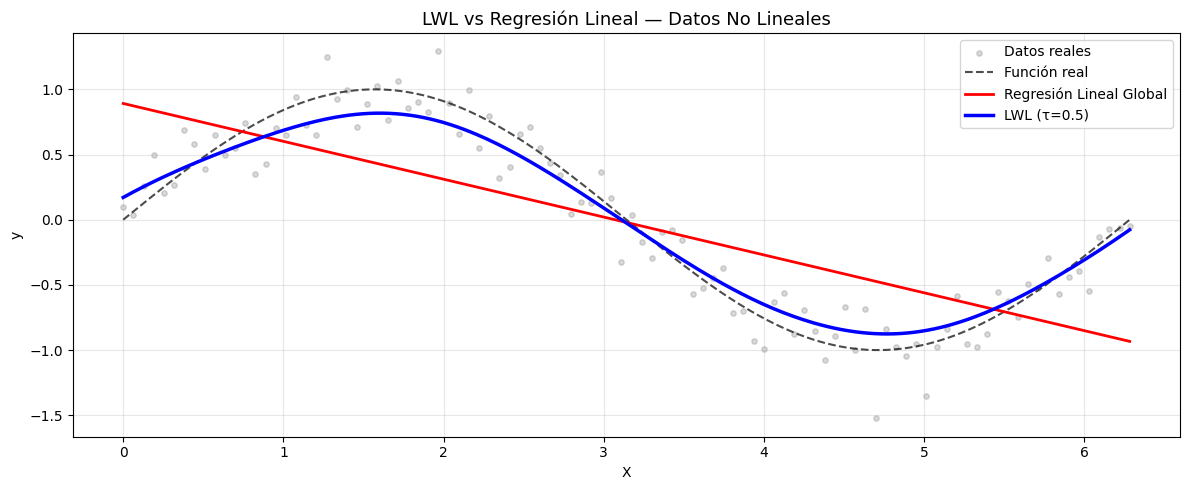

 MSE Regresión Lineal Global: 0.1992
 MSE LWL:                     0.0127
 LWL mejora en: 93.6%


In [ ]:
# ============================================================
# PASO 6: Comparación LWL vs Regresión Lineal Global
# Para demostrar cuándo LWL supera a la regresión tradicional
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Regresión Lineal Global
reg_global = LinearRegression()
reg_global.fit(X_train.reshape(-1,1), y_train)
y_global = reg_global.predict(X_query.reshape(-1,1))

# LWL con tau óptimo
y_lwl = lwl_predecir(X_query, X_train, y_train, tau=0.5)

# Función real
y_real = np.sin(X_query)

plt.figure(figsize=(12, 5))
plt.scatter(X_train, y_train, alpha=0.3, s=15, color='gray', label='Datos reales')
plt.plot(X_query, y_real, 'k--', linewidth=1.5, alpha=0.7, label='Función real')
plt.plot(X_query, y_global, 'r-', linewidth=2, label='Regresión Lineal Global')
plt.plot(X_query, y_lwl, 'b-', linewidth=2.5, label='LWL (τ=0.5)')
plt.title('LWL vs Regresión Lineal — Datos No Lineales', fontsize=13)
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mse_global = mean_squared_error(y_real, y_global)
mse_lwl = mean_squared_error(y_real, y_lwl)
print('='*45)
print(f' MSE Regresión Lineal Global: {mse_global:.4f}')
print(f' MSE LWL:                     {mse_lwl:.4f}')
print(f' LWL mejora en: {((mse_global-mse_lwl)/mse_global*100):.1f}%')
print('='*45)

## 9. Conclusiones

- **LWL** es ideal cuando los datos tienen relaciones **no lineales** que varían en distintas zonas del espacio.
- Su principal ventaja es la **flexibilidad**: no asume ninguna forma para la relación entre variables.
- Su principal desventaja es el **costo computacional**: no hay modelo pre-entrenado, todo se calcula en el momento de la predicción.
- El parámetro **τ (bandwidth)** es crítico: debe calibrarse cuidadosamente para evitar sobreajuste o subajuste.
- Es ampliamente usado en **robótica y control** donde las dinámicas locales cambian constantemente.
- En finanzas, se usa para **suavizar series de tiempo** y estimar tendencias locales.